In [1]:
# ============================================================
# PROTEIN BRANCH FINAL ANALYSIS
# Step 1: Threshold tuning
# Step 2: ROC/PR curves
# Step 3: Error analysis
# Step 4: Close protein branch
# Step 5: Prepare next branch handoff
# ============================================================

import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import joblib

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", None)

In [2]:
# ============================================================
# GOOGLE DRIVE PATHS
# Adjust if your folder differs
# ============================================================

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

MODEL_ROOT = PROJECT_DIR / "model"

# Previous result folders
HANDCRAFTED_DIR = MODEL_ROOT / "phase1_protein_baseline"

ESM2_T6_TRUNC_DIR = MODEL_ROOT / "phase1_2_esm2_embedding_baseline"
ESM2_T6_SW_DIR = MODEL_ROOT / "phase1_2_esm2_sliding_window_embedding"
ESM2_T12_TRUNC_DIR = MODEL_ROOT / "phase1_2_esm2_t12_truncated_embedding"

PROTBERT_TRUNC_DIR = MODEL_ROOT / "phase1_2_protbert_truncated_embedding"
PROTBERT_SW_DIR = MODEL_ROOT / "phase1_2_protbert_sliding_window_embedding"

# New final analysis folder
ANALYSIS_DIR = MODEL_ROOT / "phase1_final_protein_analysis"
RESULT_DIR = ANALYSIS_DIR / "results"
FIGURE_DIR = ANALYSIS_DIR / "figures"
REPORT_DIR = ANALYSIS_DIR / "reports"

for folder in [ANALYSIS_DIR, RESULT_DIR, FIGURE_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Analysis output:", ANALYSIS_DIR)

Analysis output: /content/drive/MyDrive/Project_Protein/model/phase1_final_protein_analysis


In [3]:
# ============================================================
# LOAD PROTBERT TRUNCATED MODEL + EMBEDDINGS
# ============================================================

import os
from pathlib import Path
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

# 2. Định nghĩa lại đường dẫn gốc
PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

protbert_trunc_embed_dir = PROTBERT_TRUNC_DIR / "embeddings"
protbert_trunc_model_dir = PROTBERT_TRUNC_DIR / "models"

X_train_protbert = np.load(protbert_trunc_embed_dir / "protbert_trunc_train_embeddings.npy")
X_val_protbert = np.load(protbert_trunc_embed_dir / "protbert_trunc_val_embeddings.npy")
X_test_protbert = np.load(protbert_trunc_embed_dir / "protbert_trunc_test_embeddings.npy")

meta_train_protbert = pd.read_csv(protbert_trunc_embed_dir / "protbert_trunc_train_metadata.csv")
meta_val_protbert = pd.read_csv(protbert_trunc_embed_dir / "protbert_trunc_val_metadata.csv")
meta_test_protbert = pd.read_csv(protbert_trunc_embed_dir / "protbert_trunc_test_metadata.csv")

y_train_protbert = meta_train_protbert["label"].astype(int).values
y_val_protbert = meta_val_protbert["label"].astype(int).values
y_test_protbert = meta_test_protbert["label"].astype(int).values

# Your saved final model should be Logistic Regression.
# If this filename differs, check your model folder.
protbert_trunc_model_path = protbert_trunc_model_dir / "protbert_logistic_regression_best_estimator_v1.pkl"

print("ProtBERT truncated model exists:", protbert_trunc_model_path.exists())

protbert_trunc_model = joblib.load(protbert_trunc_model_path)

print("X_train_protbert:", X_train_protbert.shape)
print("X_val_protbert:", X_val_protbert.shape)
print("X_test_protbert:", X_test_protbert.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ProtBERT truncated model exists: True
X_train_protbert: (1274, 1024)
X_val_protbert: (273, 1024)
X_test_protbert: (273, 1024)


In [5]:
# ============================================================
# LOAD PROTBERT SLIDING-WINDOW MODEL + EMBEDDINGS
# ============================================================

protbert_sw_embed_dir = PROTBERT_SW_DIR / "embeddings"
protbert_sw_model_dir = PROTBERT_SW_DIR / "models"

X_train_protbert_sw = np.load(protbert_sw_embed_dir / "protbert_sw_train_embeddings.npy")
X_val_protbert_sw = np.load(protbert_sw_embed_dir / "protbert_sw_val_embeddings.npy")
X_test_protbert_sw = np.load(protbert_sw_embed_dir / "protbert_sw_test_embeddings.npy")

meta_train_protbert_sw = pd.read_csv(protbert_sw_embed_dir / "protbert_sw_train_metadata.csv")
meta_val_protbert_sw = pd.read_csv(protbert_sw_embed_dir / "protbert_sw_val_metadata.csv")
meta_test_protbert_sw = pd.read_csv(protbert_sw_embed_dir / "protbert_sw_test_metadata.csv")

y_train_protbert_sw = meta_train_protbert_sw["label"].astype(int).values
y_val_protbert_sw = meta_val_protbert_sw["label"].astype(int).values
y_test_protbert_sw = meta_test_protbert_sw["label"].astype(int).values

protbert_sw_model_path = protbert_sw_model_dir / "protbert_sw_logistic_regression_best_estimator_v1.pkl"

print("ProtBERT sliding-window model exists:", protbert_sw_model_path.exists())

protbert_sw_model = joblib.load(protbert_sw_model_path)

print("X_train_protbert_sw:", X_train_protbert_sw.shape)
print("X_val_protbert_sw:", X_val_protbert_sw.shape)
print("X_test_protbert_sw:", X_test_protbert_sw.shape)

ProtBERT sliding-window model exists: True
X_train_protbert_sw: (1274, 1024)
X_val_protbert_sw: (273, 1024)
X_test_protbert_sw: (273, 1024)


In [6]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_positive_class_score(model, X):
    """
    Return probability/score for class 1.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    if hasattr(model, "decision_function"):
        return model.decision_function(X)

    return model.predict(X)


def evaluate_with_threshold(y_true, y_score, threshold=0.5):
    """
    Evaluate binary classifier using custom threshold.
    """
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


def tune_threshold_on_validation(
    y_val,
    y_val_score,
    metric="mcc",
    thresholds=None
):
    """
    Tune threshold on validation set.

    metric options:
    - "mcc"
    - "f1"
    - "balanced_accuracy"
    - "youden_j"
    """
    if thresholds is None:
        thresholds = np.arange(0.05, 0.951, 0.001)

    records = []

    for th in thresholds:
        metrics = evaluate_with_threshold(y_val, y_val_score, threshold=th)

        balanced_accuracy = (
            metrics["recall_sensitivity"] + metrics["specificity"]
        ) / 2

        youden_j = metrics["recall_sensitivity"] + metrics["specificity"] - 1

        metrics["balanced_accuracy"] = balanced_accuracy
        metrics["youden_j"] = youden_j

        records.append(metrics)

    df = pd.DataFrame(records)

    if metric not in df.columns:
        raise ValueError(f"Metric {metric} not found. Available: {df.columns.tolist()}")

    best_row = df.sort_values(
        by=[metric, "roc_auc", "pr_auc"],
        ascending=False
    ).iloc[0]

    return best_row, df


def build_prediction_table(meta_df, y_true, y_score, threshold, model_name, representation):
    """
    Build prediction/error analysis table.
    """
    y_pred = (y_score >= threshold).astype(int)

    pred_df = meta_df.copy()
    pred_df["true_label"] = y_true
    pred_df["pred_score"] = y_score
    pred_df["pred_label"] = y_pred
    pred_df["threshold"] = threshold
    pred_df["model_name"] = model_name
    pred_df["representation"] = representation

    def error_type(row):
        if row["true_label"] == 1 and row["pred_label"] == 1:
            return "TP"
        elif row["true_label"] == 0 and row["pred_label"] == 0:
            return "TN"
        elif row["true_label"] == 0 and row["pred_label"] == 1:
            return "FP"
        elif row["true_label"] == 1 and row["pred_label"] == 0:
            return "FN"
        else:
            return "UNKNOWN"

    pred_df["error_type"] = pred_df.apply(error_type, axis=1)

    return pred_df

In [7]:
# ============================================================
# GET VALIDATION AND TEST SCORES
# ============================================================

# ProtBERT truncated
val_score_protbert = get_positive_class_score(protbert_trunc_model, X_val_protbert)
test_score_protbert = get_positive_class_score(protbert_trunc_model, X_test_protbert)

# ProtBERT sliding-window
val_score_protbert_sw = get_positive_class_score(protbert_sw_model, X_val_protbert_sw)
test_score_protbert_sw = get_positive_class_score(protbert_sw_model, X_test_protbert_sw)

print("ProtBERT truncated val score range:", val_score_protbert.min(), val_score_protbert.max())
print("ProtBERT SW val score range:", val_score_protbert_sw.min(), val_score_protbert_sw.max())

ProtBERT truncated val score range: 0.06384783411199221 0.935996800461563
ProtBERT SW val score range: 0.07033111137856898 0.9352004595458421


In [8]:
# ============================================================
# THRESHOLD TUNING
# ============================================================

threshold_results = []
threshold_curves = {}

experiments = [
    {
        "name": "ProtBERT truncated + Logistic Regression",
        "representation": "ProtBERT_truncated_1022",
        "model": protbert_trunc_model,
        "y_val": y_val_protbert,
        "val_score": val_score_protbert,
        "y_test": y_test_protbert,
        "test_score": test_score_protbert
    },
    {
        "name": "ProtBERT sliding-window + Logistic Regression",
        "representation": "ProtBERT_sliding_window_1022_stride_1022",
        "model": protbert_sw_model,
        "y_val": y_val_protbert_sw,
        "val_score": val_score_protbert_sw,
        "y_test": y_test_protbert_sw,
        "test_score": test_score_protbert_sw
    }
]

for exp in experiments:
    print("=" * 100)
    print(exp["name"])

    for tune_metric in ["mcc", "f1", "balanced_accuracy", "youden_j"]:
        best_val_row, threshold_df = tune_threshold_on_validation(
            y_val=exp["y_val"],
            y_val_score=exp["val_score"],
            metric=tune_metric
        )

        best_threshold = float(best_val_row["threshold"])

        val_metrics = evaluate_with_threshold(
            y_true=exp["y_val"],
            y_score=exp["val_score"],
            threshold=best_threshold
        )

        test_metrics = evaluate_with_threshold(
            y_true=exp["y_test"],
            y_score=exp["test_score"],
            threshold=best_threshold
        )

        row = {
            "experiment": exp["name"],
            "representation": exp["representation"],
            "tuned_for": tune_metric,
            "best_threshold": best_threshold,

            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall_sensitivity": val_metrics["recall_sensitivity"],
            "val_specificity": val_metrics["specificity"],
            "val_f1": val_metrics["f1"],
            "val_roc_auc": val_metrics["roc_auc"],
            "val_pr_auc": val_metrics["pr_auc"],
            "val_mcc": val_metrics["mcc"],
            "val_tn": val_metrics["tn"],
            "val_fp": val_metrics["fp"],
            "val_fn": val_metrics["fn"],
            "val_tp": val_metrics["tp"],

            "test_accuracy": test_metrics["accuracy"],
            "test_precision": test_metrics["precision"],
            "test_recall_sensitivity": test_metrics["recall_sensitivity"],
            "test_specificity": test_metrics["specificity"],
            "test_f1": test_metrics["f1"],
            "test_roc_auc": test_metrics["roc_auc"],
            "test_pr_auc": test_metrics["pr_auc"],
            "test_mcc": test_metrics["mcc"],
            "test_tn": test_metrics["tn"],
            "test_fp": test_metrics["fp"],
            "test_fn": test_metrics["fn"],
            "test_tp": test_metrics["tp"],
        }

        threshold_results.append(row)

        threshold_curves[(exp["representation"], tune_metric)] = threshold_df

        print(f"Tuned for {tune_metric}")
        print("Best threshold:", best_threshold)
        print("Validation F1/MCC:", val_metrics["f1"], val_metrics["mcc"])
        print("Test F1/MCC:", test_metrics["f1"], test_metrics["mcc"])
        print()

threshold_tuning_df = pd.DataFrame(threshold_results)

display(threshold_tuning_df.sort_values(
    by=["test_mcc", "test_f1", "test_roc_auc"],
    ascending=False
))

threshold_tuning_df.to_csv(
    RESULT_DIR / "threshold_tuning_protbert_best_models.csv",
    index=False
)

ProtBERT truncated + Logistic Regression
Tuned for mcc
Best threshold: 0.3800000000000003
Validation F1/MCC: 0.7402597402597403 0.42685536601768653
Test F1/MCC: 0.6764705882352942 0.22544596465422767

Tuned for f1
Best threshold: 0.3800000000000003
Validation F1/MCC: 0.7402597402597403 0.42685536601768653
Test F1/MCC: 0.6764705882352942 0.22544596465422767

Tuned for balanced_accuracy
Best threshold: 0.3830000000000003
Validation F1/MCC: 0.738562091503268 0.4252803329894743
Test F1/MCC: 0.672566371681416 0.2159608262756479

Tuned for youden_j
Best threshold: 0.3830000000000003
Validation F1/MCC: 0.738562091503268 0.4252803329894743
Test F1/MCC: 0.672566371681416 0.2159608262756479

ProtBERT sliding-window + Logistic Regression
Tuned for mcc
Best threshold: 0.4250000000000003
Validation F1/MCC: 0.7241379310344828 0.41653375160526085
Test F1/MCC: 0.6222222222222222 0.13611214011319886

Tuned for f1
Best threshold: 0.34800000000000025
Validation F1/MCC: 0.7339449541284404 0.39261734310248

,experiment,representation,tuned_for,best_threshold,val_accuracy,val_precision,val_recall_sensitivity,val_specificity,val_f1,val_roc_auc,val_pr_auc,val_mcc,val_tn,val_fp,val_fn,val_tp,test_accuracy,test_precision,test_recall_sensitivity,test_specificity,test_f1,test_roc_auc,test_pr_auc,test_mcc,test_tn,test_fp,test_fn,test_tp
5,ProtBERT sliding-window + Logistic Regression,ProtBERT_sliding_window_1022_stride_1022,f1,0.348,0.681319,0.631579,0.875912,0.485294,0.733945,0.738622,0.706355,0.392617,66,70,17,120,0.589744,0.553097,0.919118,0.262774,0.690608,0.648723,0.655100,0.240901,36,101,11,125
0,ProtBERT truncated + Logistic Regression,ProtBERT_truncated_1022,mcc,0.380,0.706960,0.666667,0.832117,0.580882,0.740260,0.746136,0.715048,0.426855,79,57,23,114,0.597070,0.563725,0.845588,0.350365,0.676471,0.637076,0.642279,0.225446,48,89,21,115
1,ProtBERT truncated + Logistic Regression,ProtBERT_truncated_1022,f1,0.380,0.706960,0.666667,0.832117,0.580882,0.740260,0.746136,0.715048,0.426855,79,57,23,114,0.597070,0.563725,0.845588,0.350365,0.676471,0.637076,0.642279,0.225446,48,89,21,115
2,ProtBERT truncated + Logistic Regression,ProtBERT_truncated_1022,balanced_accuracy,0.383,0.706960,0.668639,0.824818,0.588235,0.738562,0.746136,0.715048,0.425280,80,56,24,113,0.593407,0.561576,0.838235,0.350365,0.672566,0.637076,0.642279,0.215961,48,89,22,114
3,ProtBERT truncated + Logistic Regression,ProtBERT_truncated_1022,youden_j,0.383,0.706960,0.668639,0.824818,0.588235,0.738562,0.746136,0.715048,0.425280,80,56,24,113,0.593407,0.561576,0.838235,0.350365,0.672566,0.637076,0.642279,0.215961,48,89,22,114
4,ProtBERT sliding-window + Logistic Regression,ProtBERT_sliding_window_1022_stride_1022,mcc,0.425,0.706960,0.686275,0.766423,0.647059,0.724138,0.738622,0.706355,0.416534,88,48,32,105,0.564103,0.547486,0.720588,0.408759,0.622222,0.648723,0.655100,0.136112,56,81,38,98
6,ProtBERT sliding-window + Logistic Regression,ProtBERT_sliding_window_1022_stride_1022,balanced_accuracy,0.425,0.706960,0.686275,0.766423,0.647059,0.724138,0.738622,0.706355,0.416534,88,48,32,105,0.564103,0.547486,0.720588,0.408759,0.622222,0.648723,0.655100,0.136112,56,81,38,98
7,ProtBERT sliding-window + Logistic Regression,ProtBERT_sliding_window_1022_stride_1022,youden_j,0.425,0.706960,0.686275,0.766423,0.647059,0.724138,0.738622,0.706355,0.416534,88,48,32,105,0.564103,0.547486,0.720588,0.408759,0.622222,0.648723,0.655100,0.136112,56,81,38,98


In [9]:
# ============================================================
# THRESHOLD TUNING
# ============================================================

threshold_results = []
threshold_curves = {}

experiments = [
    {
        "name": "ProtBERT truncated + Logistic Regression",
        "representation": "ProtBERT_truncated_1022",
        "model": protbert_trunc_model,
        "y_val": y_val_protbert,
        "val_score": val_score_protbert,
        "y_test": y_test_protbert,
        "test_score": test_score_protbert
    },
    {
        "name": "ProtBERT sliding-window + Logistic Regression",
        "representation": "ProtBERT_sliding_window_1022_stride_1022",
        "model": protbert_sw_model,
        "y_val": y_val_protbert_sw,
        "val_score": val_score_protbert_sw,
        "y_test": y_test_protbert_sw,
        "test_score": test_score_protbert_sw
    }
]

for exp in experiments:
    print("=" * 100)
    print(exp["name"])

    for tune_metric in ["mcc", "f1", "balanced_accuracy", "youden_j"]:
        best_val_row, threshold_df = tune_threshold_on_validation(
            y_val=exp["y_val"],
            y_val_score=exp["val_score"],
            metric=tune_metric
        )

        best_threshold = float(best_val_row["threshold"])

        val_metrics = evaluate_with_threshold(
            y_true=exp["y_val"],
            y_score=exp["val_score"],
            threshold=best_threshold
        )

        test_metrics = evaluate_with_threshold(
            y_true=exp["y_test"],
            y_score=exp["test_score"],
            threshold=best_threshold
        )

        row = {
            "experiment": exp["name"],
            "representation": exp["representation"],
            "tuned_for": tune_metric,
            "best_threshold": best_threshold,

            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall_sensitivity": val_metrics["recall_sensitivity"],
            "val_specificity": val_metrics["specificity"],
            "val_f1": val_metrics["f1"],
            "val_roc_auc": val_metrics["roc_auc"],
            "val_pr_auc": val_metrics["pr_auc"],
            "val_mcc": val_metrics["mcc"],
            "val_tn": val_metrics["tn"],
            "val_fp": val_metrics["fp"],
            "val_fn": val_metrics["fn"],
            "val_tp": val_metrics["tp"],

            "test_accuracy": test_metrics["accuracy"],
            "test_precision": test_metrics["precision"],
            "test_recall_sensitivity": test_metrics["recall_sensitivity"],
            "test_specificity": test_metrics["specificity"],
            "test_f1": test_metrics["f1"],
            "test_roc_auc": test_metrics["roc_auc"],
            "test_pr_auc": test_metrics["pr_auc"],
            "test_mcc": test_metrics["mcc"],
            "test_tn": test_metrics["tn"],
            "test_fp": test_metrics["fp"],
            "test_fn": test_metrics["fn"],
            "test_tp": test_metrics["tp"],
        }

        threshold_results.append(row)

        threshold_curves[(exp["representation"], tune_metric)] = threshold_df

        print(f"Tuned for {tune_metric}")
        print("Best threshold:", best_threshold)
        print("Validation F1/MCC:", val_metrics["f1"], val_metrics["mcc"])
        print("Test F1/MCC:", test_metrics["f1"], test_metrics["mcc"])
        print()

threshold_tuning_df = pd.DataFrame(threshold_results)

display(threshold_tuning_df.sort_values(
    by=["test_mcc", "test_f1", "test_roc_auc"],
    ascending=False
))

threshold_tuning_df.to_csv(
    RESULT_DIR / "threshold_tuning_protbert_best_models.csv",
    index=False
)

ProtBERT truncated + Logistic Regression
Tuned for mcc
Best threshold: 0.3800000000000003
Validation F1/MCC: 0.7402597402597403 0.42685536601768653
Test F1/MCC: 0.6764705882352942 0.22544596465422767

Tuned for f1
Best threshold: 0.3800000000000003
Validation F1/MCC: 0.7402597402597403 0.42685536601768653
Test F1/MCC: 0.6764705882352942 0.22544596465422767

Tuned for balanced_accuracy
Best threshold: 0.3830000000000003
Validation F1/MCC: 0.738562091503268 0.4252803329894743
Test F1/MCC: 0.672566371681416 0.2159608262756479

Tuned for youden_j
Best threshold: 0.3830000000000003
Validation F1/MCC: 0.738562091503268 0.4252803329894743
Test F1/MCC: 0.672566371681416 0.2159608262756479

ProtBERT sliding-window + Logistic Regression
Tuned for mcc
Best threshold: 0.4250000000000003
Validation F1/MCC: 0.7241379310344828 0.41653375160526085
Test F1/MCC: 0.6222222222222222 0.13611214011319886

Tuned for f1
Best threshold: 0.34800000000000025
Validation F1/MCC: 0.7339449541284404 0.39261734310248

,experiment,representation,tuned_for,best_threshold,val_accuracy,val_precision,val_recall_sensitivity,val_specificity,val_f1,val_roc_auc,val_pr_auc,val_mcc,val_tn,val_fp,val_fn,val_tp,test_accuracy,test_precision,test_recall_sensitivity,test_specificity,test_f1,test_roc_auc,test_pr_auc,test_mcc,test_tn,test_fp,test_fn,test_tp
5,ProtBERT sliding-window + Logistic Regression,ProtBERT_sliding_window_1022_stride_1022,f1,0.348,0.681319,0.631579,0.875912,0.485294,0.733945,0.738622,0.706355,0.392617,66,70,17,120,0.589744,0.553097,0.919118,0.262774,0.690608,0.648723,0.655100,0.240901,36,101,11,125
0,ProtBERT truncated + Logistic Regression,ProtBERT_truncated_1022,mcc,0.380,0.706960,0.666667,0.832117,0.580882,0.740260,0.746136,0.715048,0.426855,79,57,23,114,0.597070,0.563725,0.845588,0.350365,0.676471,0.637076,0.642279,0.225446,48,89,21,115
1,ProtBERT truncated + Logistic Regression,ProtBERT_truncated_1022,f1,0.380,0.706960,0.666667,0.832117,0.580882,0.740260,0.746136,0.715048,0.426855,79,57,23,114,0.597070,0.563725,0.845588,0.350365,0.676471,0.637076,0.642279,0.225446,48,89,21,115
2,ProtBERT truncated + Logistic Regression,ProtBERT_truncated_1022,balanced_accuracy,0.383,0.706960,0.668639,0.824818,0.588235,0.738562,0.746136,0.715048,0.425280,80,56,24,113,0.593407,0.561576,0.838235,0.350365,0.672566,0.637076,0.642279,0.215961,48,89,22,114
3,ProtBERT truncated + Logistic Regression,ProtBERT_truncated_1022,youden_j,0.383,0.706960,0.668639,0.824818,0.588235,0.738562,0.746136,0.715048,0.425280,80,56,24,113,0.593407,0.561576,0.838235,0.350365,0.672566,0.637076,0.642279,0.215961,48,89,22,114
4,ProtBERT sliding-window + Logistic Regression,ProtBERT_sliding_window_1022_stride_1022,mcc,0.425,0.706960,0.686275,0.766423,0.647059,0.724138,0.738622,0.706355,0.416534,88,48,32,105,0.564103,0.547486,0.720588,0.408759,0.622222,0.648723,0.655100,0.136112,56,81,38,98
6,ProtBERT sliding-window + Logistic Regression,ProtBERT_sliding_window_1022_stride_1022,balanced_accuracy,0.425,0.706960,0.686275,0.766423,0.647059,0.724138,0.738622,0.706355,0.416534,88,48,32,105,0.564103,0.547486,0.720588,0.408759,0.622222,0.648723,0.655100,0.136112,56,81,38,98
7,ProtBERT sliding-window + Logistic Regression,ProtBERT_sliding_window_1022_stride_1022,youden_j,0.425,0.706960,0.686275,0.766423,0.647059,0.724138,0.738622,0.706355,0.416534,88,48,32,105,0.564103,0.547486,0.720588,0.408759,0.622222,0.648723,0.655100,0.136112,56,81,38,98


In [10]:
# ============================================================
# DEFAULT THRESHOLD VS TUNED THRESHOLD
# ============================================================

default_records = []

for exp in experiments:
    val_default = evaluate_with_threshold(
        y_true=exp["y_val"],
        y_score=exp["val_score"],
        threshold=0.5
    )

    test_default = evaluate_with_threshold(
        y_true=exp["y_test"],
        y_score=exp["test_score"],
        threshold=0.5
    )

    default_records.append({
        "experiment": exp["name"],
        "representation": exp["representation"],
        "threshold": 0.5,
        "val_f1": val_default["f1"],
        "val_mcc": val_default["mcc"],
        "test_f1": test_default["f1"],
        "test_mcc": test_default["mcc"],
        "test_roc_auc": test_default["roc_auc"],
        "test_pr_auc": test_default["pr_auc"],
        "test_tn": test_default["tn"],
        "test_fp": test_default["fp"],
        "test_fn": test_default["fn"],
        "test_tp": test_default["tp"]
    })

default_threshold_df = pd.DataFrame(default_records)

display(default_threshold_df)

default_threshold_df.to_csv(
    RESULT_DIR / "default_threshold_protbert_best_models.csv",
    index=False
)

,experiment,representation,threshold,val_f1,val_mcc,test_f1,test_mcc,test_roc_auc,test_pr_auc,test_tn,test_fp,test_fn,test_tp
0,ProtBERT truncated + Logistic Regression,ProtBERT_truncated_1022,0.5,0.664093,0.365095,0.601449,0.194298,0.637076,0.642279,80,57,53,83
1,ProtBERT sliding-window + Logistic Regression,ProtBERT_sliding_window_1022_stride_1022,0.5,0.664122,0.356891,0.589552,0.194125,0.648723,0.655100,84,53,57,79


In [11]:
# ============================================================
# LOAD FINAL TEST PREDICTIONS FROM PREVIOUS PHASES
# ============================================================

candidate_prediction_files = [
    {
        "label": "ProtBERT truncated",
        "path": PROTBERT_TRUNC_DIR / "results" / "protbert_final_test_predictions_v1.csv",
        "score_col_candidates": ["pred_score_t2d_associated", "pred_score", "score"],
        "true_col_candidates": ["true_label", "label"]
    },
    {
        "label": "ProtBERT sliding-window",
        "path": PROTBERT_SW_DIR / "results" / "protbert_sw_final_test_predictions_v1.csv",
        "score_col_candidates": ["pred_score_t2d_associated", "pred_score", "score"],
        "true_col_candidates": ["true_label", "label"]
    },
    {
        "label": "ESM2_t6 truncated",
        "path": ESM2_T6_TRUNC_DIR / "results" / "esm2_final_test_predictions_v1.csv",
        "score_col_candidates": ["pred_score_t2d_associated", "pred_score", "score"],
        "true_col_candidates": ["true_label", "label"]
    },
    {
        "label": "ESM2_t6 sliding-window",
        "path": ESM2_T6_SW_DIR / "results" / "esm2_sw_final_test_predictions_v1.csv",
        "score_col_candidates": ["pred_score_t2d_associated", "pred_score", "score"],
        "true_col_candidates": ["true_label", "label"]
    },
    {
        "label": "ESM2_t12 truncated",
        "path": ESM2_T12_TRUNC_DIR / "results" / "esm2_t12_final_test_predictions_v1.csv",
        "score_col_candidates": ["pred_score_t2d_associated", "pred_score", "score"],
        "true_col_candidates": ["true_label", "label"]
    }
]


def find_first_existing_col(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


curve_data = []

for item in candidate_prediction_files:
    path = item["path"]

    if not path.exists():
        print("Missing prediction file, skipped:", item["label"], path)
        continue

    df_pred = pd.read_csv(path)

    score_col = find_first_existing_col(df_pred, item["score_col_candidates"])
    true_col = find_first_existing_col(df_pred, item["true_col_candidates"])

    if score_col is None or true_col is None:
        print("Missing score/true col, skipped:", item["label"])
        print("Columns:", df_pred.columns.tolist())
        continue

    y_true = df_pred[true_col].astype(int).values
    y_score = df_pred[score_col].astype(float).values

    curve_data.append({
        "label": item["label"],
        "y_true": y_true,
        "y_score": y_score
    })

    print("Loaded:", item["label"], "| n =", len(y_true), "| ROC-AUC =", roc_auc_score(y_true, y_score))

Loaded: ProtBERT truncated | n = 273 | ROC-AUC = 0.6370759982825247
Loaded: ProtBERT sliding-window | n = 273 | ROC-AUC = 0.6487226277372263
Missing prediction file, skipped: ESM2_t6 truncated /content/drive/MyDrive/Project_Protein/model/phase1_2_esm2_embedding_baseline/results/esm2_final_test_predictions_v1.csv
Loaded: ESM2_t6 sliding-window | n = 273 | ROC-AUC = 0.6276835551738944
Loaded: ESM2_t12 truncated | n = 273 | ROC-AUC = 0.5874838986689567


In [12]:
# ============================================================
# ENSURE BEST PROTBERT MODELS ARE INCLUDED
# ============================================================

curve_data_direct = [
    {
        "label": "ProtBERT truncated LR",
        "y_true": y_test_protbert,
        "y_score": test_score_protbert
    },
    {
        "label": "ProtBERT sliding-window LR",
        "y_true": y_test_protbert_sw,
        "y_score": test_score_protbert_sw
    }
]

# Avoid duplicates by label
existing_labels = {d["label"] for d in curve_data}

for item in curve_data_direct:
    if item["label"] not in existing_labels:
        curve_data.append(item)

print("Total curves:", len(curve_data))
for item in curve_data:
    print(item["label"])

Total curves: 6
ProtBERT truncated
ProtBERT sliding-window
ESM2_t6 sliding-window
ESM2_t12 truncated
ProtBERT truncated LR
ProtBERT sliding-window LR


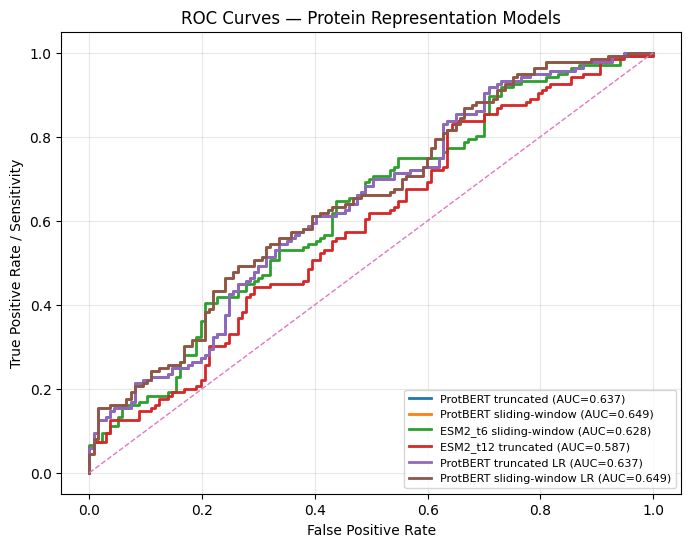

,model,roc_auc
1,ProtBERT sliding-window,0.648723
5,ProtBERT sliding-window LR,0.648723
0,ProtBERT truncated,0.637076
4,ProtBERT truncated LR,0.637076
2,ESM2_t6 sliding-window,0.627684
3,ESM2_t12 truncated,0.587484


Saved ROC figure: /content/drive/MyDrive/Project_Protein/model/phase1_final_protein_analysis/figures/roc_curves_protein_representations.png


In [13]:
# ============================================================
# ROC CURVE
# ============================================================

plt.figure(figsize=(8, 6))

roc_summary_records = []

for item in curve_data:
    y_true = item["y_true"]
    y_score = item["y_score"]

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)

    plt.plot(fpr, tpr, linewidth=2, label=f"{item['label']} (AUC={roc_auc:.3f})")

    roc_summary_records.append({
        "model": item["label"],
        "roc_auc": roc_auc
    })

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")
plt.title("ROC Curves — Protein Representation Models")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True, alpha=0.3)

roc_fig_path = FIGURE_DIR / "roc_curves_protein_representations.png"
plt.savefig(roc_fig_path, dpi=300, bbox_inches="tight")
plt.show()

roc_summary_df = pd.DataFrame(roc_summary_records).sort_values(
    by="roc_auc",
    ascending=False
)

display(roc_summary_df)

roc_summary_df.to_csv(
    RESULT_DIR / "roc_curve_summary.csv",
    index=False
)

print("Saved ROC figure:", roc_fig_path)

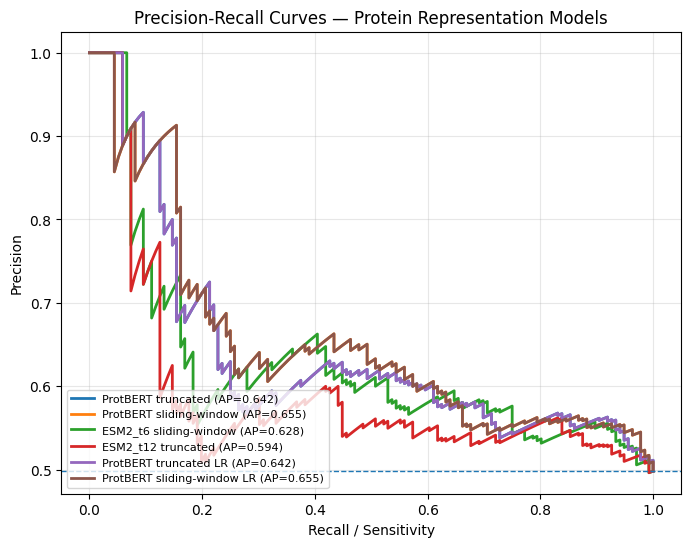

,model,pr_auc
1,ProtBERT sliding-window,0.655100
5,ProtBERT sliding-window LR,0.655100
0,ProtBERT truncated,0.642279
4,ProtBERT truncated LR,0.642279
2,ESM2_t6 sliding-window,0.627788
3,ESM2_t12 truncated,0.594175


Saved PR figure: /content/drive/MyDrive/Project_Protein/model/phase1_final_protein_analysis/figures/pr_curves_protein_representations.png


In [14]:
# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

plt.figure(figsize=(8, 6))

pr_summary_records = []

for item in curve_data:
    y_true = item["y_true"]
    y_score = item["y_score"]

    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)

    plt.plot(recall, precision, linewidth=2, label=f"{item['label']} (AP={pr_auc:.3f})")

    pr_summary_records.append({
        "model": item["label"],
        "pr_auc": pr_auc
    })

positive_rate = np.mean(curve_data[0]["y_true"])
plt.axhline(y=positive_rate, linestyle="--", linewidth=1)

plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — Protein Representation Models")
plt.legend(loc="lower left", fontsize=8)
plt.grid(True, alpha=0.3)

pr_fig_path = FIGURE_DIR / "pr_curves_protein_representations.png"
plt.savefig(pr_fig_path, dpi=300, bbox_inches="tight")
plt.show()

pr_summary_df = pd.DataFrame(pr_summary_records).sort_values(
    by="pr_auc",
    ascending=False
)

display(pr_summary_df)

pr_summary_df.to_csv(
    RESULT_DIR / "pr_curve_summary.csv",
    index=False
)

print("Saved PR figure:", pr_fig_path)

In [15]:
# ============================================================
# SELECT THRESHOLD POLICY FOR ERROR ANALYSIS
# ============================================================

THRESHOLD_POLICY = "mcc"  # options: "mcc", "f1", "balanced_accuracy", "youden_j"

selected_threshold_rows = threshold_tuning_df[
    threshold_tuning_df["tuned_for"] == THRESHOLD_POLICY
].copy()

display(selected_threshold_rows[[
    "experiment",
    "best_threshold",
    "val_f1",
    "val_mcc",
    "test_f1",
    "test_mcc",
    "test_roc_auc",
    "test_pr_auc"
]])

selected_threshold_rows.to_csv(
    RESULT_DIR / f"selected_thresholds_tuned_for_{THRESHOLD_POLICY}.csv",
    index=False
)

,experiment,best_threshold,val_f1,val_mcc,test_f1,test_mcc,test_roc_auc,test_pr_auc
0,ProtBERT truncated + Logistic Regression,0.380,0.740260,0.426855,0.676471,0.225446,0.637076,0.642279
4,ProtBERT sliding-window + Logistic Regression,0.425,0.724138,0.416534,0.622222,0.136112,0.648723,0.655100


In [16]:
# ============================================================
# BUILD ERROR ANALYSIS TABLES
# ============================================================

# Get thresholds
threshold_map = {
    row["representation"]: row["best_threshold"]
    for _, row in selected_threshold_rows.iterrows()
}

protbert_trunc_threshold = threshold_map["ProtBERT_truncated_1022"]
protbert_sw_threshold = threshold_map["ProtBERT_sliding_window_1022_stride_1022"]

print("ProtBERT truncated threshold:", protbert_trunc_threshold)
print("ProtBERT sliding-window threshold:", protbert_sw_threshold)

protbert_trunc_pred_df = build_prediction_table(
    meta_df=meta_test_protbert,
    y_true=y_test_protbert,
    y_score=test_score_protbert,
    threshold=protbert_trunc_threshold,
    model_name="Logistic Regression",
    representation="ProtBERT_truncated_1022"
)

protbert_sw_pred_df = build_prediction_table(
    meta_df=meta_test_protbert_sw,
    y_true=y_test_protbert_sw,
    y_score=test_score_protbert_sw,
    threshold=protbert_sw_threshold,
    model_name="Logistic Regression",
    representation="ProtBERT_sliding_window_1022_stride_1022"
)

display(protbert_trunc_pred_df.head())
display(protbert_sw_pred_df.head())

protbert_trunc_pred_df.to_csv(
    RESULT_DIR / "error_analysis_protbert_truncated_test_predictions.csv",
    index=False
)

protbert_sw_pred_df.to_csv(
    RESULT_DIR / "error_analysis_protbert_sliding_window_test_predictions.csv",
    index=False
)

ProtBERT truncated threshold: 0.3800000000000003
ProtBERT sliding-window threshold: 0.4250000000000003


,row_index,gene_id,gene_symbol,uniprot_accession,label,sequence_clean_length,truncated,used_length,max_aa_length,representation,true_label,pred_score,pred_label,threshold,model_name,error_type
0,0,ENSG00000177542,SLC25A22,Q9H936,0,323,False,323,1022,ProtBERT_truncated_1022,0,0.767247,1,0.38,Logistic Regression,FP
1,1,ENSG00000123080,CDKN2C,P42773,1,168,False,168,1022,ProtBERT_truncated_1022,1,0.451194,1,0.38,Logistic Regression,TP
2,2,ENSG00000185262,UBALD2,Q8IYN6,0,164,False,164,1022,ProtBERT_truncated_1022,0,0.765832,1,0.38,Logistic Regression,FP
3,3,ENSG00000092148,HECTD1,Q9ULT8,0,2610,True,1022,1022,ProtBERT_truncated_1022,0,0.465261,1,0.38,Logistic Regression,FP
4,4,ENSG00000139364,TMEM132B,Q14DG7,1,1078,True,1022,1022,ProtBERT_truncated_1022,1,0.543085,1,0.38,Logistic Regression,TP


,row_index,gene_id,gene_symbol,uniprot_accession,label,sequence_clean_length,n_windows,window_size,stride,representation,true_label,pred_score,pred_label,threshold,model_name,error_type
0,0,ENSG00000177542,SLC25A22,Q9H936,0,323,1,1022,1022,ProtBERT_sliding_window_1022_stride_1022,0,0.758499,1,0.425,Logistic Regression,FP
1,1,ENSG00000123080,CDKN2C,P42773,1,168,1,1022,1022,ProtBERT_sliding_window_1022_stride_1022,1,0.464095,1,0.425,Logistic Regression,TP
2,2,ENSG00000185262,UBALD2,Q8IYN6,0,164,1,1022,1022,ProtBERT_sliding_window_1022_stride_1022,0,0.806849,1,0.425,Logistic Regression,FP
3,3,ENSG00000092148,HECTD1,Q9ULT8,0,2610,3,1022,1022,ProtBERT_sliding_window_1022_stride_1022,0,0.613123,1,0.425,Logistic Regression,FP
4,4,ENSG00000139364,TMEM132B,Q14DG7,1,1078,2,1022,1022,ProtBERT_sliding_window_1022_stride_1022,1,0.493005,1,0.425,Logistic Regression,TP


In [17]:
# ============================================================
# ERROR TYPE SUMMARY
# ============================================================

error_summary_records = []

for name, pred_df in [
    ("ProtBERT truncated", protbert_trunc_pred_df),
    ("ProtBERT sliding-window", protbert_sw_pred_df)
]:
    counts = pred_df["error_type"].value_counts().to_dict()

    error_summary_records.append({
        "model": name,
        "TP": counts.get("TP", 0),
        "TN": counts.get("TN", 0),
        "FP": counts.get("FP", 0),
        "FN": counts.get("FN", 0),
        "n": len(pred_df),
        "fp_rate_among_actual_negative": counts.get("FP", 0) / max((counts.get("FP", 0) + counts.get("TN", 0)), 1),
        "fn_rate_among_actual_positive": counts.get("FN", 0) / max((counts.get("FN", 0) + counts.get("TP", 0)), 1),
    })

error_summary_df = pd.DataFrame(error_summary_records)

display(error_summary_df)

error_summary_df.to_csv(
    RESULT_DIR / "error_type_summary_best_protbert_models.csv",
    index=False
)

,model,TP,TN,FP,FN,n,fp_rate_among_actual_negative,fn_rate_among_actual_positive
0,ProtBERT truncated,115,48,89,21,273,0.649635,0.154412
1,ProtBERT sliding-window,98,56,81,38,273,0.591241,0.279412


In [18]:
# ============================================================
# HIGH-CONFIDENCE ERRORS
# ============================================================

def get_high_confidence_errors(pred_df, top_n=20):
    """
    FP high confidence: label 0 but high predicted score
    FN high confidence: label 1 but low predicted score
    """
    fp_high = pred_df[pred_df["error_type"] == "FP"].sort_values(
        by="pred_score",
        ascending=False
    ).head(top_n)

    fn_high = pred_df[pred_df["error_type"] == "FN"].sort_values(
        by="pred_score",
        ascending=True
    ).head(top_n)

    return fp_high, fn_high


for name, pred_df, prefix in [
    ("ProtBERT truncated", protbert_trunc_pred_df, "protbert_truncated"),
    ("ProtBERT sliding-window", protbert_sw_pred_df, "protbert_sliding_window")
]:
    print("=" * 100)
    print(name)

    fp_high, fn_high = get_high_confidence_errors(pred_df, top_n=20)

    print("High-confidence false positives:")
    display(fp_high[[
        "gene_id",
        "gene_symbol",
        "uniprot_accession",
        "true_label",
        "pred_label",
        "pred_score",
        "error_type",
        "sequence_clean_length"
    ]])

    print("High-confidence false negatives:")
    display(fn_high[[
        "gene_id",
        "gene_symbol",
        "uniprot_accession",
        "true_label",
        "pred_label",
        "pred_score",
        "error_type",
        "sequence_clean_length"
    ]])

    fp_high.to_csv(
        RESULT_DIR / f"high_confidence_false_positives_{prefix}.csv",
        index=False
    )

    fn_high.to_csv(
        RESULT_DIR / f"high_confidence_false_negatives_{prefix}.csv",
        index=False
    )

ProtBERT truncated
High-confidence false positives:


,gene_id,gene_symbol,uniprot_accession,true_label,pred_label,pred_score,error_type,sequence_clean_length
188,ENSG00000078687,TNRC6C,Q9HCJ0,0,1,0.861993,FP,1936
96,ENSG00000182575,NXPH3,O95157,0,1,0.779756,FP,252
0,ENSG00000177542,SLC25A22,Q9H936,0,1,0.767247,FP,323
2,ENSG00000185262,UBALD2,Q8IYN6,0,1,0.765832,FP,164
134,ENSG00000213782,DDX47,Q9H0S4,0,1,0.762715,FP,455
79,ENSG00000134287,ARF3,P61204,0,1,0.746843,FP,181
227,ENSG00000189108,IL1RAPL2,Q9NP60,0,1,0.745097,FP,686
144,ENSG00000124067,SLC12A4,Q9UP95,0,1,0.742932,FP,1085
184,ENSG00000110881,ASIC1,P78348,0,1,0.735435,FP,528
182,ENSG00000074695,LMAN1,P49257,0,1,0.731180,FP,510


High-confidence false negatives:


,gene_id,gene_symbol,uniprot_accession,true_label,pred_label,pred_score,error_type,sequence_clean_length
127,ENSG00000198089,SFI1,A8K8P3,1,0,0.150093,FN,1242
61,ENSG00000156920,ADGRG4,Q8IZF6,1,0,0.209433,FN,3080
103,ENSG00000103932,RPAP1,Q9BWH6,1,0,0.211600,FN,1393
53,ENSG00000203760,CENPW,Q5EE01,1,0,0.240130,FN,88
204,ENSG00000144712,CAND2,O75155,1,0,0.255771,FN,1236
175,ENSG00000008710,PKD1,P98161,1,0,0.272444,FN,4303
198,ENSG00000187240,DYNC2H1,Q8NCM8,1,0,0.291673,FN,4307
59,ENSG00000153820,SPHKAP,Q2M3C7,1,0,0.312197,FN,1700
264,ENSG00000188352,FOCAD,Q5VW36,1,0,0.320029,FN,1801
11,ENSG00000160185,UBASH3A,P57075,1,0,0.333282,FN,661


ProtBERT sliding-window
High-confidence false positives:


,gene_id,gene_symbol,uniprot_accession,true_label,pred_label,pred_score,error_type,sequence_clean_length
188,ENSG00000078687,TNRC6C,Q9HCJ0,0,1,0.885428,FP,1936
2,ENSG00000185262,UBALD2,Q8IYN6,0,1,0.806849,FP,164
134,ENSG00000213782,DDX47,Q9H0S4,0,1,0.759756,FP,455
0,ENSG00000177542,SLC25A22,Q9H936,0,1,0.758499,FP,323
96,ENSG00000182575,NXPH3,O95157,0,1,0.757968,FP,252
227,ENSG00000189108,IL1RAPL2,Q9NP60,0,1,0.752818,FP,686
184,ENSG00000110881,ASIC1,P78348,0,1,0.750606,FP,528
79,ENSG00000134287,ARF3,P61204,0,1,0.748537,FP,181
182,ENSG00000074695,LMAN1,P49257,0,1,0.747721,FP,510
8,ENSG00000111711,GOLT1B,Q9Y3E0,0,1,0.727538,FP,138


High-confidence false negatives:


,gene_id,gene_symbol,uniprot_accession,true_label,pred_label,pred_score,error_type,sequence_clean_length
127,ENSG00000198089,SFI1,A8K8P3,1,0,0.155978,FN,1242
103,ENSG00000103932,RPAP1,Q9BWH6,1,0,0.217752,FN,1393
53,ENSG00000203760,CENPW,Q5EE01,1,0,0.239648,FN,88
94,ENSG00000185436,IFNLR1,Q8IU57,1,0,0.289734,FN,520
175,ENSG00000008710,PKD1,P98161,1,0,0.297736,FN,4303
197,ENSG00000126266,FFAR1,O14842,1,0,0.316421,FN,300
61,ENSG00000156920,ADGRG4,Q8IZF6,1,0,0.318580,FN,3080
40,ENSG00000087448,KLHL42,Q9P2K6,1,0,0.326462,FN,505
211,ENSG00000140464,PML,P29590,1,0,0.333943,FN,882
203,ENSG00000056972,TRAF3IP2,O43734,1,0,0.337393,FN,574


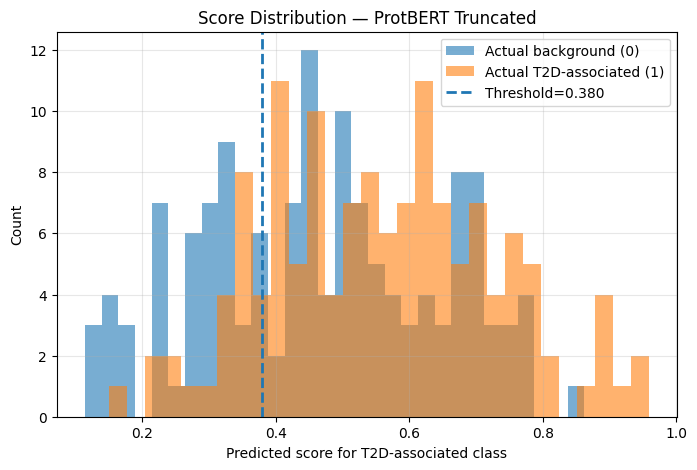

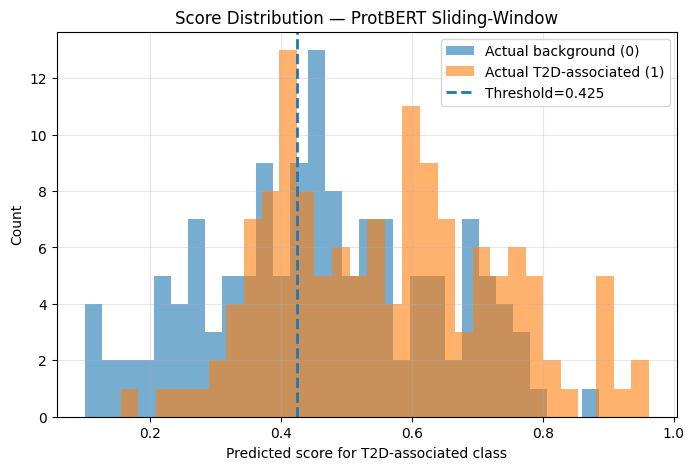

In [19]:
# ============================================================
# SCORE DISTRIBUTION BY TRUE CLASS
# ============================================================

def plot_score_distribution(pred_df, title, output_path):
    plt.figure(figsize=(8, 5))

    scores_0 = pred_df[pred_df["true_label"] == 0]["pred_score"]
    scores_1 = pred_df[pred_df["true_label"] == 1]["pred_score"]

    plt.hist(scores_0, bins=30, alpha=0.6, label="Actual background (0)")
    plt.hist(scores_1, bins=30, alpha=0.6, label="Actual T2D-associated (1)")

    threshold = pred_df["threshold"].iloc[0]
    plt.axvline(threshold, linestyle="--", linewidth=2, label=f"Threshold={threshold:.3f}")

    plt.xlabel("Predicted score for T2D-associated class")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_score_distribution(
    protbert_trunc_pred_df,
    title="Score Distribution — ProtBERT Truncated",
    output_path=FIGURE_DIR / "score_distribution_protbert_truncated.png"
)

plot_score_distribution(
    protbert_sw_pred_df,
    title="Score Distribution — ProtBERT Sliding-Window",
    output_path=FIGURE_DIR / "score_distribution_protbert_sliding_window.png"
)

In [20]:
# ============================================================
# COMPARE TRUNCATED VS SLIDING-WINDOW PREDICTIONS
# ============================================================

compare_cols = [
    "gene_id",
    "gene_symbol",
    "uniprot_accession",
    "true_label",
    "pred_score",
    "pred_label",
    "error_type",
    "sequence_clean_length"
]

trunc_compare = protbert_trunc_pred_df[compare_cols].copy()
trunc_compare = trunc_compare.rename(columns={
    "pred_score": "trunc_score",
    "pred_label": "trunc_pred",
    "error_type": "trunc_error",
    "sequence_clean_length": "sequence_length"
})

sw_compare = protbert_sw_pred_df[compare_cols].copy()
sw_compare = sw_compare.rename(columns={
    "pred_score": "sw_score",
    "pred_label": "sw_pred",
    "error_type": "sw_error",
    "sequence_clean_length": "sequence_length_sw"
})

comparison_error_df = trunc_compare.merge(
    sw_compare.drop(columns=["gene_symbol", "true_label"]),
    on=["gene_id", "uniprot_accession"],
    how="inner"
)

comparison_error_df["score_diff_sw_minus_trunc"] = (
    comparison_error_df["sw_score"] - comparison_error_df["trunc_score"]
)

comparison_error_df["same_prediction"] = (
    comparison_error_df["trunc_pred"] == comparison_error_df["sw_pred"]
)

comparison_error_df["same_error_type"] = (
    comparison_error_df["trunc_error"] == comparison_error_df["sw_error"]
)

display(comparison_error_df.head())

print("Same prediction rate:", comparison_error_df["same_prediction"].mean())
print("Same error type rate:", comparison_error_df["same_error_type"].mean())

comparison_error_df.to_csv(
    RESULT_DIR / "compare_protbert_truncated_vs_sliding_window_predictions.csv",
    index=False
)

,gene_id,gene_symbol,uniprot_accession,true_label,trunc_score,trunc_pred,trunc_error,sequence_length,sw_score,sw_pred,sw_error,sequence_length_sw,score_diff_sw_minus_trunc,same_prediction,same_error_type
0,ENSG00000177542,SLC25A22,Q9H936,0,0.767247,1,FP,323,0.758499,1,FP,323,-0.008748,True,True
1,ENSG00000123080,CDKN2C,P42773,1,0.451194,1,TP,168,0.464095,1,TP,168,0.012900,True,True
2,ENSG00000185262,UBALD2,Q8IYN6,0,0.765832,1,FP,164,0.806849,1,FP,164,0.041017,True,True
3,ENSG00000092148,HECTD1,Q9ULT8,0,0.465261,1,FP,2610,0.613123,1,FP,2610,0.147862,True,True
4,ENSG00000139364,TMEM132B,Q14DG7,1,0.543085,1,TP,1078,0.493005,1,TP,1078,-0.050080,True,True


Same prediction rate: 0.8864468864468864
Same error type rate: 0.8864468864468864


In [21]:
# ============================================================
# FINAL MASTER COMPARISON TABLE
# ============================================================

master_rows = [
    {
        "phase": "1.1",
        "representation": "AAC + Physchem",
        "embedding_policy": "handcrafted",
        "final_model": "Random Forest",
        "test_roc_auc": 0.5520,
        "test_pr_auc": 0.5550,
        "test_f1": 0.5390,
        "test_mcc": 0.0480,
        "status": "baseline"
    },
    {
        "phase": "1.2A",
        "representation": "ESM2_t6_8M",
        "embedding_policy": "truncated_1022",
        "final_model": "Stacking",
        "test_roc_auc": 0.6202,
        "test_pr_auc": 0.6188,
        "test_f1": 0.5926,
        "test_mcc": 0.1941,
        "status": "foundation_embedding"
    },
    {
        "phase": "1.2B",
        "representation": "ESM2_t6_8M",
        "embedding_policy": "sliding_window_1022_stride_1022",
        "final_model": "Soft Voting",
        "test_roc_auc": 0.6277,
        "test_pr_auc": 0.6278,
        "test_f1": 0.5870,
        "test_mcc": 0.1650,
        "status": "foundation_embedding"
    },
    {
        "phase": "1.2C",
        "representation": "ESM2_t12_35M",
        "embedding_policy": "truncated_1022",
        "final_model": "Soft Voting",
        "test_roc_auc": 0.5875,
        "test_pr_auc": 0.5942,
        "test_f1": 0.5654,
        "test_mcc": 0.0995,
        "status": "foundation_embedding"
    },
    {
        "phase": "1.2D",
        "representation": "ProtBERT",
        "embedding_policy": "truncated_1022",
        "final_model": "Logistic Regression",
        "test_roc_auc": 0.6371,
        "test_pr_auc": 0.6423,
        "test_f1": 0.6014,
        "test_mcc": 0.1943,
        "status": "best_f1_mcc"
    },
    {
        "phase": "1.2E",
        "representation": "ProtBERT",
        "embedding_policy": "sliding_window_1022_stride_1022",
        "final_model": "Logistic Regression",
        "test_roc_auc": 0.6487,
        "test_pr_auc": 0.6551,
        "test_f1": 0.5896,
        "test_mcc": 0.1941,
        "status": "best_roc_pr"
    }
]

protein_master_df = pd.DataFrame(master_rows)

protein_master_df = protein_master_df.sort_values(
    by="test_roc_auc",
    ascending=False
)

display(protein_master_df)

protein_master_df.to_csv(
    RESULT_DIR / "final_protein_branch_master_comparison.csv",
    index=False
)

,phase,representation,embedding_policy,final_model,test_roc_auc,test_pr_auc,test_f1,test_mcc,status
5,1.2E,ProtBERT,sliding_window_1022_stride_1022,Logistic Regression,0.6487,0.6551,0.5896,0.1941,best_roc_pr
4,1.2D,ProtBERT,truncated_1022,Logistic Regression,0.6371,0.6423,0.6014,0.1943,best_f1_mcc
2,1.2B,ESM2_t6_8M,sliding_window_1022_stride_1022,Soft Voting,0.6277,0.6278,0.5870,0.1650,foundation_embedding
1,1.2A,ESM2_t6_8M,truncated_1022,Stacking,0.6202,0.6188,0.5926,0.1941,foundation_embedding
3,1.2C,ESM2_t12_35M,truncated_1022,Soft Voting,0.5875,0.5942,0.5654,0.0995,foundation_embedding
0,1.1,AAC + Physchem,handcrafted,Random Forest,0.5520,0.5550,0.5390,0.0480,baseline


In [22]:
# ============================================================
# AUTO-GENERATE PROTEIN BRANCH SUMMARY TEXT
# ============================================================

best_roc_row = protein_master_df.sort_values("test_roc_auc", ascending=False).iloc[0]
best_f1_row = protein_master_df.sort_values("test_f1", ascending=False).iloc[0]
best_mcc_row = protein_master_df.sort_values("test_mcc", ascending=False).iloc[0]

summary_text = f"""
# Final Protein Branch Summary

The protein representation branch compared handcrafted protein descriptors, ESM-2 embeddings, and ProtBERT embeddings for T2D-associated protein classification.

The handcrafted AAC + physicochemical baseline achieved weak test performance:
- ROC-AUC = 0.5520
- PR-AUC = 0.5550
- F1 = 0.5390
- MCC = 0.0480

Protein foundation embeddings improved performance substantially.

Best final-selected representation by ROC-AUC:
- Phase: {best_roc_row['phase']}
- Representation: {best_roc_row['representation']}
- Embedding policy: {best_roc_row['embedding_policy']}
- Final model: {best_roc_row['final_model']}
- Test ROC-AUC = {best_roc_row['test_roc_auc']:.4f}
- Test PR-AUC = {best_roc_row['test_pr_auc']:.4f}
- Test F1 = {best_roc_row['test_f1']:.4f}
- Test MCC = {best_roc_row['test_mcc']:.4f}

Best final-selected representation by F1:
- Phase: {best_f1_row['phase']}
- Representation: {best_f1_row['representation']}
- Embedding policy: {best_f1_row['embedding_policy']}
- Final model: {best_f1_row['final_model']}
- Test F1 = {best_f1_row['test_f1']:.4f}

Best final-selected representation by MCC:
- Phase: {best_mcc_row['phase']}
- Representation: {best_mcc_row['representation']}
- Embedding policy: {best_mcc_row['embedding_policy']}
- Final model: {best_mcc_row['final_model']}
- Test MCC = {best_mcc_row['test_mcc']:.4f}

Main conclusion:
Protein language model embeddings outperform handcrafted descriptors.
ProtBERT is the strongest representation family in this protein-only branch.
However, performance remains moderate, suggesting that protein sequence alone is insufficient for highly accurate T2D association prediction.
The next stage should integrate genomic, regulatory, pathway, or evidence-based features.
"""

summary_path = REPORT_DIR / "final_protein_branch_summary.md"

with open(summary_path, "w") as f:
    f.write(summary_text)

print(summary_text)
print("Saved:", summary_path)


# Final Protein Branch Summary

The protein representation branch compared handcrafted protein descriptors, ESM-2 embeddings, and ProtBERT embeddings for T2D-associated protein classification.

The handcrafted AAC + physicochemical baseline achieved weak test performance:
- ROC-AUC = 0.5520
- PR-AUC = 0.5550
- F1 = 0.5390
- MCC = 0.0480

Protein foundation embeddings improved performance substantially.

Best final-selected representation by ROC-AUC:
- Phase: 1.2E
- Representation: ProtBERT
- Embedding policy: sliding_window_1022_stride_1022
- Final model: Logistic Regression
- Test ROC-AUC = 0.6487
- Test PR-AUC = 0.6551
- Test F1 = 0.5896
- Test MCC = 0.1941

Best final-selected representation by F1:
- Phase: 1.2D
- Representation: ProtBERT
- Embedding policy: truncated_1022
- Final model: Logistic Regression
- Test F1 = 0.6014

Best final-selected representation by MCC:
- Phase: 1.2D
- Representation: ProtBERT
- Embedding policy: truncated_1022
- Final model: Logistic Regression
- T

In [23]:
# ============================================================
# SAVE SELECTED REPRESENTATION CONFIG
# ============================================================

selected_protein_config = {
    "primary_representation": {
        "name": "ProtBERT sliding-window",
        "embedding_policy": "sliding_window_1022_stride_1022",
        "model": "Rostlab/prot_bert",
        "pooling": "mean token pooling per window + mean window pooling",
        "downstream_model": "Logistic Regression",
        "reason": "Best final-selected ROC-AUC and PR-AUC",
        "test_roc_auc": 0.6487,
        "test_pr_auc": 0.6551,
        "test_f1": 0.5896,
        "test_mcc": 0.1941,
        "embedding_files": {
            "train": str(PROTBERT_SW_DIR / "embeddings" / "protbert_sw_train_embeddings.npy"),
            "validation": str(PROTBERT_SW_DIR / "embeddings" / "protbert_sw_val_embeddings.npy"),
            "test": str(PROTBERT_SW_DIR / "embeddings" / "protbert_sw_test_embeddings.npy")
        },
        "metadata_files": {
            "train": str(PROTBERT_SW_DIR / "embeddings" / "protbert_sw_train_metadata.csv"),
            "validation": str(PROTBERT_SW_DIR / "embeddings" / "protbert_sw_val_metadata.csv"),
            "test": str(PROTBERT_SW_DIR / "embeddings" / "protbert_sw_test_metadata.csv")
        }
    },
    "secondary_representation": {
        "name": "ProtBERT truncated",
        "embedding_policy": "truncated_1022",
        "model": "Rostlab/prot_bert",
        "pooling": "mean token pooling",
        "downstream_model": "Logistic Regression",
        "reason": "Best final-selected F1 and MCC, cheaper than sliding-window",
        "test_roc_auc": 0.6371,
        "test_pr_auc": 0.6423,
        "test_f1": 0.6014,
        "test_mcc": 0.1943,
        "embedding_files": {
            "train": str(PROTBERT_TRUNC_DIR / "embeddings" / "protbert_trunc_train_embeddings.npy"),
            "validation": str(PROTBERT_TRUNC_DIR / "embeddings" / "protbert_trunc_val_embeddings.npy"),
            "test": str(PROTBERT_TRUNC_DIR / "embeddings" / "protbert_trunc_test_embeddings.npy")
        },
        "metadata_files": {
            "train": str(PROTBERT_TRUNC_DIR / "embeddings" / "protbert_trunc_train_metadata.csv"),
            "validation": str(PROTBERT_TRUNC_DIR / "embeddings" / "protbert_trunc_val_metadata.csv"),
            "test": str(PROTBERT_TRUNC_DIR / "embeddings" / "protbert_trunc_test_metadata.csv")
        }
    },
    "next_recommended_branch": {
        "branch": "genomic/regulatory representation",
        "reason": "Protein sequence alone provides moderate predictive signal. T2D association likely requires gene regulation, pathway context, tissue expression, and genetic evidence.",
        "recommended_next_features": [
            "gene-level genomic features",
            "promoter/enhancer sequence embeddings",
            "SNP/GWAS context",
            "Open Targets evidence features",
            "GO/pathway features",
            "PPI/network features"
        ]
    }
}

config_path = REPORT_DIR / "selected_protein_representation_handoff.json"

with open(config_path, "w") as f:
    json.dump(selected_protein_config, f, indent=4)

print("Saved config:", config_path)

Saved config: /content/drive/MyDrive/Project_Protein/model/phase1_final_protein_analysis/reports/selected_protein_representation_handoff.json


In [ ]:
# ============================================================
# CREATE INTEGRATION-READY PROTEIN FEATURE FILES
# These files can be used later for multi-modal integration.
# ============================================================

def create_integration_feature_table(X, meta_df, prefix):
    """
    Convert embedding matrix to DataFrame with gene metadata.
    """
    feature_cols = [f"{prefix}_{i}" for i in range(X.shape[1])]

    X_df = pd.DataFrame(X, columns=feature_cols)

    metadata_cols = []
    for col in ["gene_id", "gene_symbol", "uniprot_accession", "label"]:
        if col in meta_df.columns:
            metadata_cols.append(col)

    out_df = pd.concat(
        [
            meta_df[metadata_cols].reset_index(drop=True),
            X_df.reset_index(drop=True)
        ],
        axis=1
    )

    return out_df


# Primary: ProtBERT sliding-window
train_protein_features = create_integration_feature_table(
    X_train_sw_protbert,
    meta_train_sw_protbert,
    prefix="protbert_sw"
)

val_protein_features = create_integration_feature_table(
    X_val_sw_protbert,
    meta_val_sw_protbert,
    prefix="protbert_sw"
)

test_protein_features = create_integration_feature_table(
    X_test_sw_protbert,
    meta_test_sw_protbert,
    prefix="protbert_sw"
)

train_protein_features.to_csv(
    RESULT_DIR / "integration_ready_train_protbert_sw_features.csv",
    index=False
)

val_protein_features.to_csv(
    RESULT_DIR / "integration_ready_val_protbert_sw_features.csv",
    index=False
)

test_protein_features.to_csv(
    RESULT_DIR / "integration_ready_test_protbert_sw_features.csv",
    index=False
)

print("Integration-ready files saved.")
print(train_protein_features.shape)
print(val_protein_features.shape)
print(test_protein_features.shape)

In [26]:
final_recommended_models = pd.DataFrame([
    {
        "use_case": "Ranking / candidate prioritization",
        "recommended_representation": "ProtBERT sliding-window",
        "model": "Logistic Regression",
        "threshold": "Not required",
        "test_roc_auc": 0.648723,
        "test_pr_auc": 0.655100,
        "test_f1": None,
        "test_mcc": None,
        "main_reason": "Best ROC-AUC and PR-AUC"
    },
    {
        "use_case": "Binary classification - high recall",
        "recommended_representation": "ProtBERT sliding-window",
        "model": "Logistic Regression",
        "threshold": 0.348,
        "test_roc_auc": 0.648723,
        "test_pr_auc": 0.655100,
        "test_f1": 0.690608,
        "test_mcc": 0.240901,
        "main_reason": "Best tuned F1 and MCC on test"
    },
    {
        "use_case": "Binary classification - more conservative",
        "recommended_representation": "ProtBERT truncated",
        "model": "Logistic Regression",
        "threshold": 0.380,
        "test_roc_auc": 0.637076,
        "test_pr_auc": 0.642279,
        "test_f1": 0.676471,
        "test_mcc": 0.225446,
        "main_reason": "Strong F1/MCC with simpler embedding"
    }
])

display(final_recommended_models)

final_recommended_models.to_csv(
    RESULT_DIR / "final_recommended_protein_models.csv",
    index=False
)

,use_case,recommended_representation,model,threshold,test_roc_auc,test_pr_auc,test_f1,test_mcc,main_reason
0,Ranking / candidate prioritization,ProtBERT sliding-window,Logistic Regression,Not required,0.648723,0.655100,NaN,NaN,Best ROC-AUC and PR-AUC
1,Binary classification - high recall,ProtBERT sliding-window,Logistic Regression,0.348,0.648723,0.655100,0.690608,0.240901,Best tuned F1 and MCC on test
2,Binary classification - more conservative,ProtBERT truncated,Logistic Regression,0.38,0.637076,0.642279,0.676471,0.225446,Strong F1/MCC with simpler embedding
